<a href="https://colab.research.google.com/github/lamihaA/INTERNSHIP/blob/main/DAY_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [ ]:
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


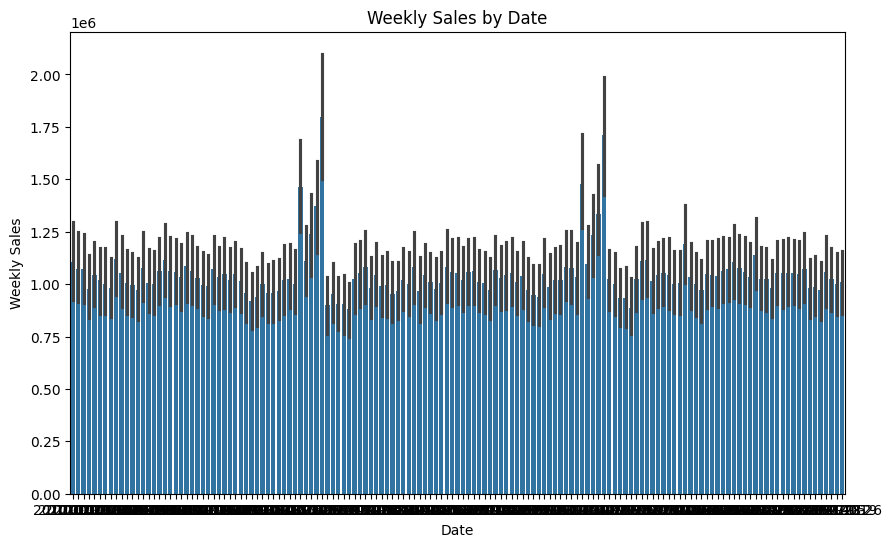

In [2]:
data.info()
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data['Year'] = data['Date'].dt.year

data['Month'] = data['Date'].dt.month

data['Day'] = data['Date'].dt.day

data[['Date','Year','Month','Day']].head()
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,6))
sns.barplot(data = data, x = data['Date'], y = data['Weekly_Sales'])
plt.title('Weekly Sales by Date')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.show()


/tmp/ipykernel_782/3937327865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = data['Holiday_Flag'], y = data['Weekly_Sales'], palette = 'Set2')


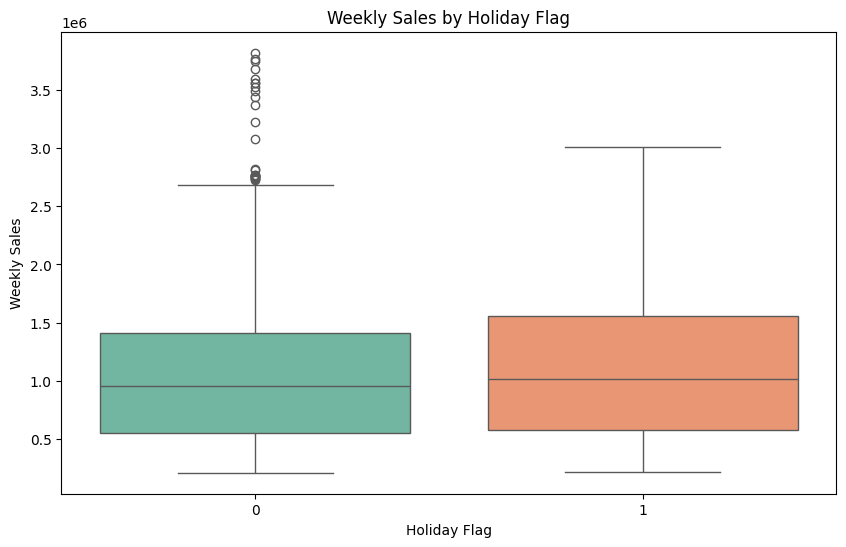

/tmp/ipykernel_782/3937327865.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = data['Holiday_Flag'], y = data['Weekly_Sales'], palette = 'Set2')


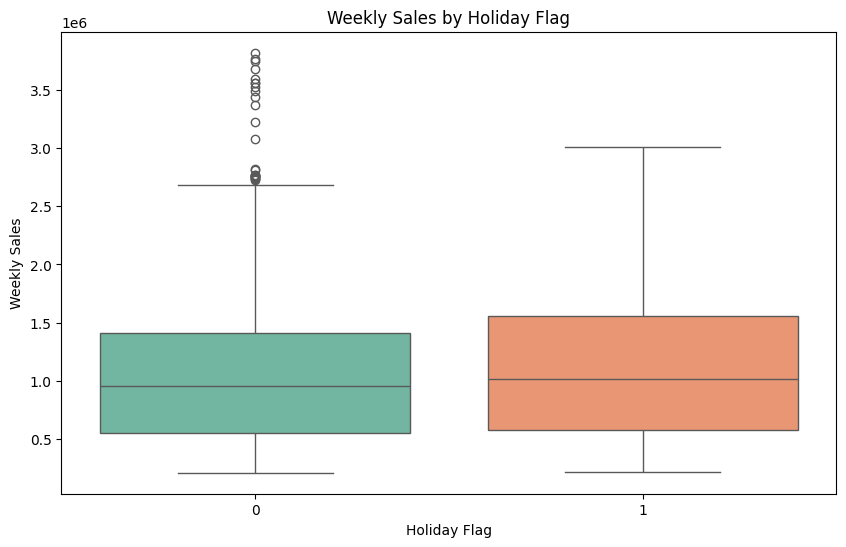

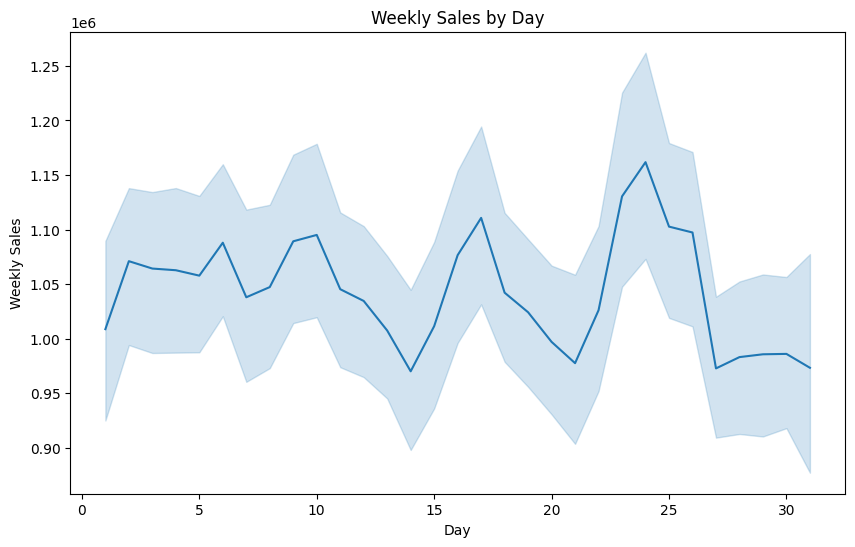

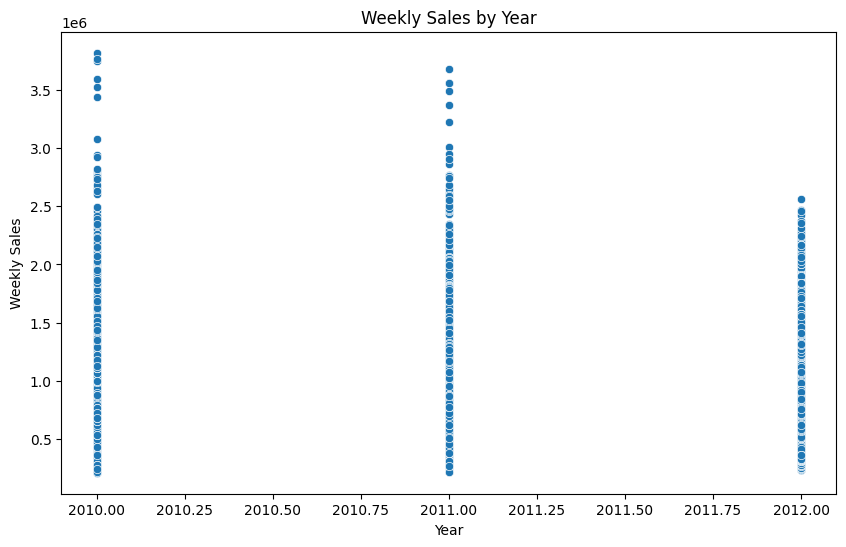

In [3]:
plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = data['Holiday_Flag'], y = data['Weekly_Sales'], palette = 'Set2')
plt.title('Weekly Sales by Holiday Flag')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.show()
plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = data['Holiday_Flag'], y = data['Weekly_Sales'], palette = 'Set2')
plt.title('Weekly Sales by Holiday Flag')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.show()
plt.figure(figsize = (10,6))
sns.lineplot(data = data, x = data['Day'], y = data['Weekly_Sales'])
plt.title('Weekly Sales by Day')
plt.xlabel('Day')
plt.ylabel('Weekly Sales')

plt.show()

plt.figure(figsize = (10,6))
sns.scatterplot(data = data, x = data['Year'], y = data['Weekly_Sales'])
plt.title('Weekly Sales by Year')
plt.xlabel('Year')
plt.ylabel('Weekly Sales')

plt.show()

/tmp/ipykernel_782/3682785124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = data, x = data['Year'], y = data['Weekly_Sales'], palette = 'Set3')


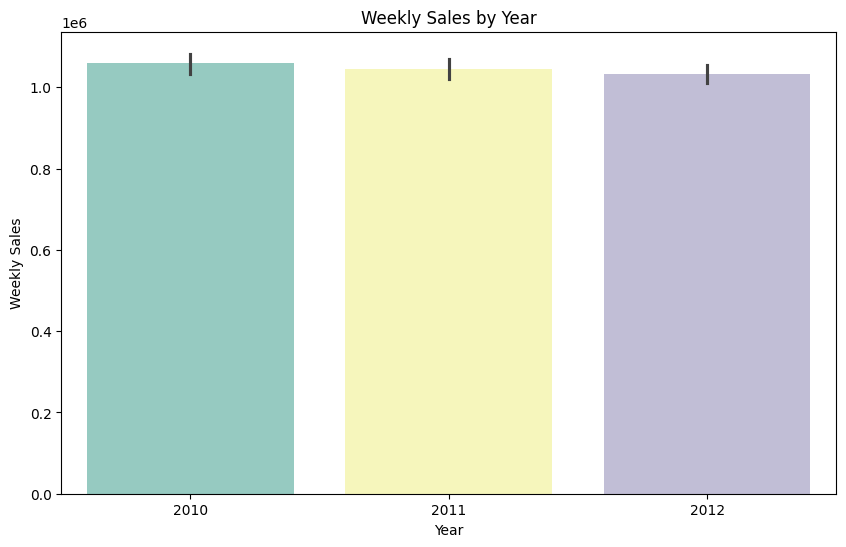

/tmp/ipykernel_782/3682785124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = data, x = data['Month'], y = data['Weekly_Sales'], palette = 'coolwarm')


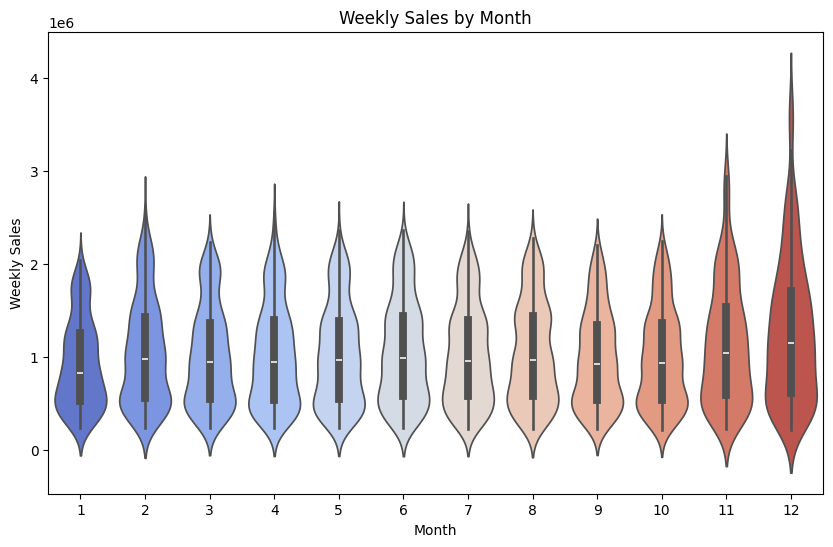

In [4]:
plt.figure(figsize = (10,6))
sns.barplot(data = data, x = data['Year'], y = data['Weekly_Sales'], palette = 'Set3')
plt.title('Weekly Sales by Year')
plt.xlabel('Year')
plt.ylabel('Weekly Sales')

plt.show()

plt.figure(figsize = (10,6))
sns.violinplot(data = data, x = data['Month'], y = data['Weekly_Sales'], palette = 'coolwarm')
plt.title('Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Weekly Sales')

plt.show()



In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = data.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and Date as it's not numerical
y = data["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


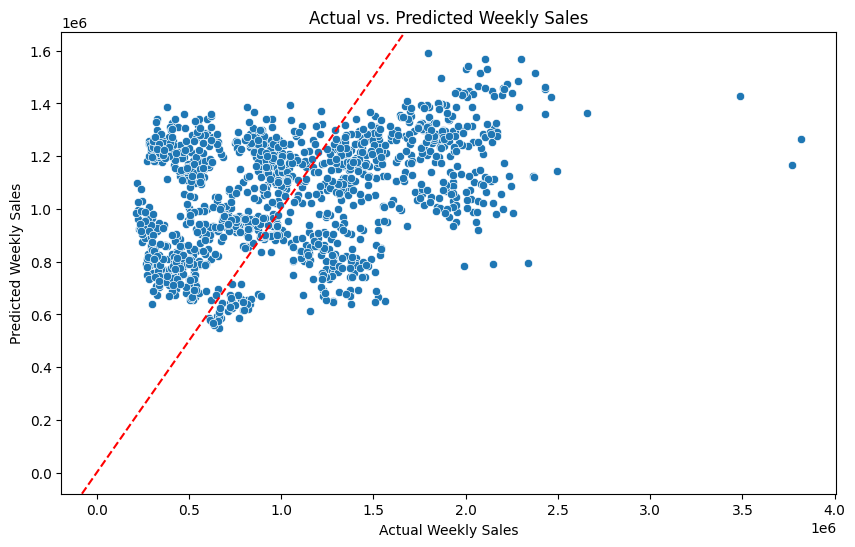

In [6]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = y_test, y = y_pred)
plt.title('Actual vs. Predicted Weekly Sales')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.axline([0,0],[1,1],color="red",linestyle='--')
plt.show()

In [7]:
from scipy.stats import skew

In [8]:
skewness = data.drop(columns=['Date']).skew(numeric_only=True)

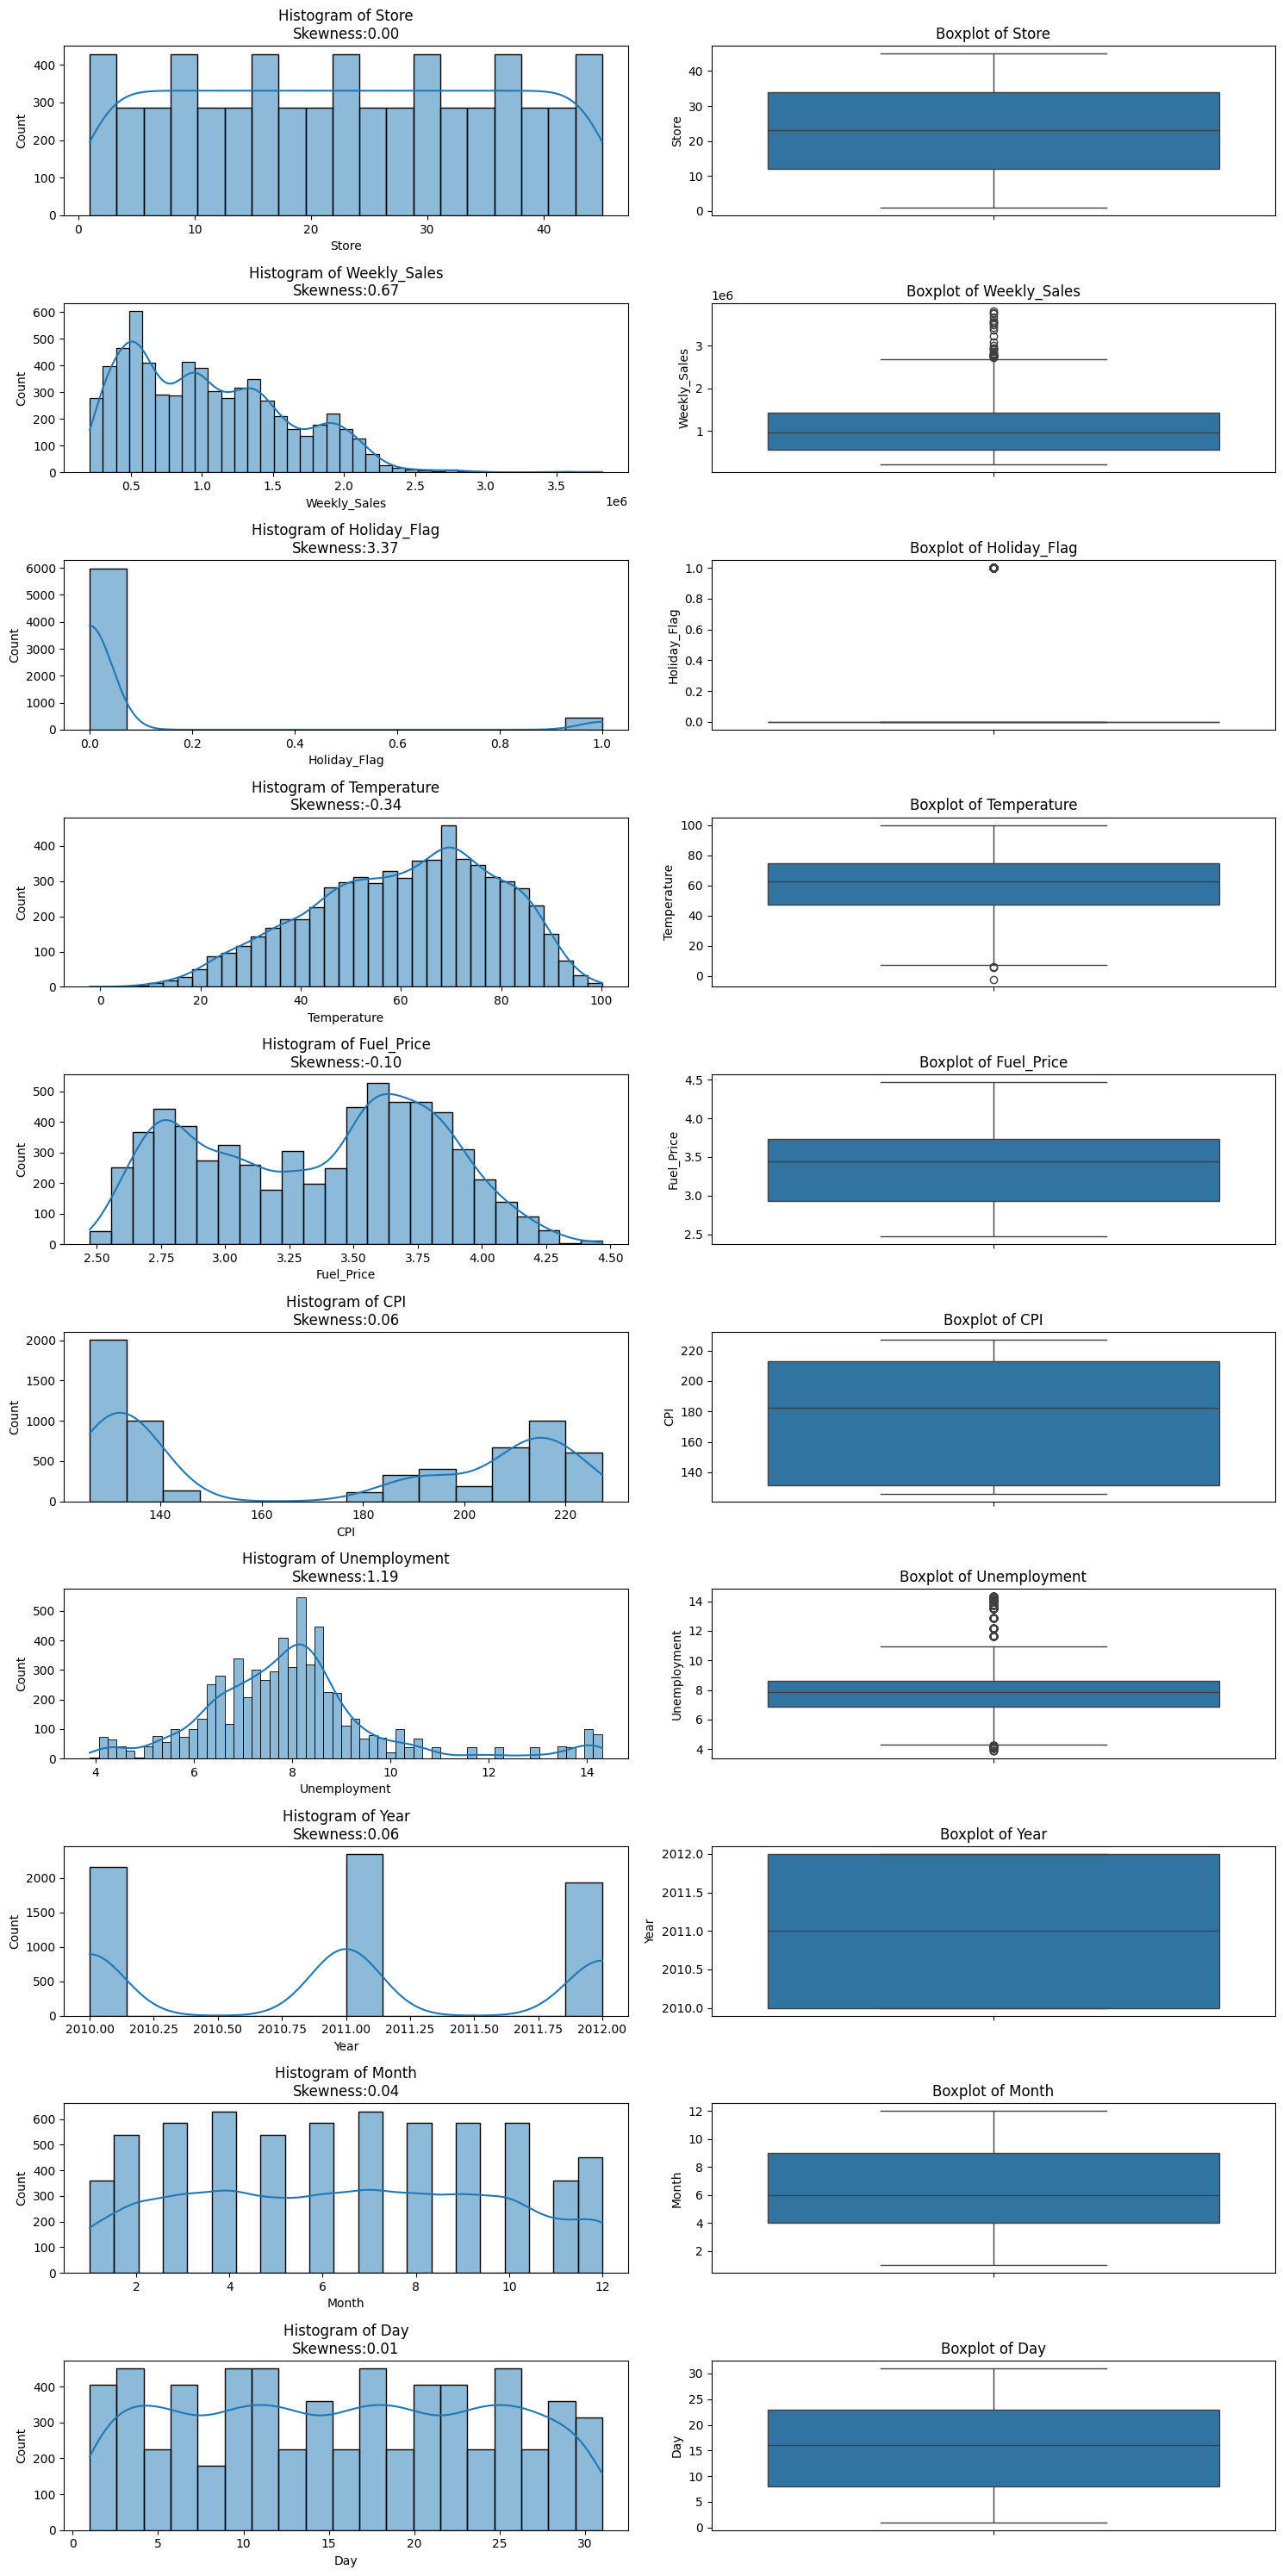

In [9]:
num_cols = len(skewness.index)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(skewness.index):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(data[col],kde=True)
  plt.title(f'Histogram of {col}\nSkewness:{skewness[col]:.2f}')

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(data[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
#find highly skewed columns
skewed_cols = data.drop(columns=['Date']).skew(numeric_only=True).abs()
highly_skewed = skewed_cols[skewed_cols >1].index
negatively_skewed = skewed_cols[skewed_cols <1].index
print("Highly Skewed Columns:\n", highly_skewed)
print("Negatively Skewed Columns:\n", negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [11]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# Step 1: Log Transformation
data['Unemployment_Log'] = np.log1p(data['Unemployment'])

# Step 2: Robust Scaling
robust_scaler = RobustScaler()

data['Unemployment_Log_Robust'] = robust_scaler.fit_transform(
    data[['Unemployment_Log']]
)

# Check results
print(data[['Unemployment',
            'Unemployment_Log',
            'Unemployment_Log_Robust']].head())

   Unemployment  Unemployment_Log  Unemployment_Log_Robust
0         8.106          2.208934                 0.130126
1         8.106          2.208934                 0.130126
2         8.106          2.208934                 0.130126
3         8.106          2.208934                 0.130126
4         8.106          2.208934                 0.130126


In [12]:
print("Original Skewness:",
      data['Unemployment'].skew())
print("After Log Transform:",
      data['Unemployment_Log'].skew())

Original Skewness: 1.1881439334843265
After Log Transform: 0.22699141149270227


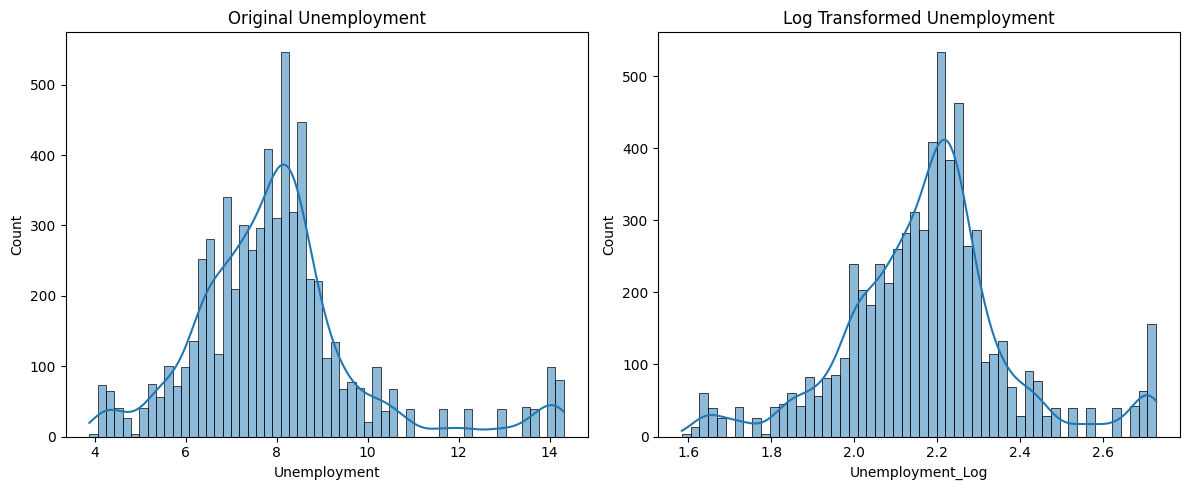

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data['Unemployment'], kde=True)
plt.title("Original Unemployment")

plt.subplot(1,2,2)
sns.histplot(data['Unemployment_Log'], kde=True)
plt.title("Log Transformed Unemployment")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = data.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and Date as it's not numerical
y = data["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1574
RMSE: 521000.1613


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

#Train Model
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("Random Forest R²:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

print("Linear Regression R²:", r2)

print("Random Forest R²:", r2_rf)



Random Forest R²: 0.9585742544838018
Random Forest RMSE: 115522.69478937316
Linear Regression R²: 0.15741945687535708
Random Forest R²: 0.9585742544838018


In [17]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Store,0.663974
4,CPI,0.151977
5,Unemployment,0.042854
9,Unemployment_Log,0.032380
10,Unemployment_Log_Robust,0.031967
7,Month,0.029998
8,Day,0.018863
2,Temperature,0.012924
3,Fuel_Price,0.010933
1,Holiday_Flag,0.003183
